In [1]:
# ERA5 point pull (hourly) for:
#  - Incoming shortwave (ssrd) -> W m-2
#  - Net radiation = (ssr + str) -> W m-2
#  - Air temperature at 50 m AGL from model levels -> K, C
#  - Specific humidity at 50 m AGL -> kg/kg + RH %
#
# Conda:
#   mamba install -c conda-forge cdsapi xarray netcdf4 cfgrib numpy pandas matplotlib
#
# Notes:
# - This version does NOT import/use the Python `eccodes` package directly.
# - Some CDS NetCDFs use `valid_time` instead of `time`; we normalize that.
# - Do NOT overwrite your configured client later (no second cdsapi.Client()).

import calendar
from pathlib import Path
from typing import List, Tuple

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import os
import cdsapi

# ----------------------------
# AUTH / CLIENT (set once)
# ----------------------------
# Prefer storing these as environment variables outside the notebook.
# If you set them here, restart kernel before sharing the notebook.
import os
import cdsapi
# put your personal access token in an env var (or paste it here)
os.environ["CDSAPI_URL"] = "https://cds.climate.copernicus.eu/api"
os.environ["CDSAPI_KEY"] = "26adf827-f30d-4793-a33e-749b08372309"

c = cdsapi.Client(url=os.environ["CDSAPI_URL"], key=os.environ["CDSAPI_KEY"])

# ----------------------------
# USER INPUTS
# ----------------------------
lat = 38.54

lon = -121.75
start = "2022-06-01"  # UTC
end   = "2022-06-07"  # UTC

target_height_m = 50.0
n_lowest_levels = 30  # more levels = safer height interp, bigger download

workdir = Path("era5_point_download")
out_csv = Path("era5_point_timeseries.csv")
workdir.mkdir(parents=True, exist_ok=True)


2026-01-01 09:58:19,171 INFO [2025-12-03T00:00:00Z] To improve our C3S service, we need to hear from you! Please complete this very short [survey](https://confluence.ecmwf.int/x/E7uBEQ/). Thank you.


In [2]:
# from pathlib import Path
# import cdsapi
# import xarray as xr

# date_utc = "2022-06-01"
# CA_AREA = [42.1, -124.6, 32.5, -114.1]
# LOWEST_10_LEVELS = "/".join(str(L) for L in range(128, 138))
# outdir = Path("era5_ca_day")
# outdir.mkdir(parents=True, exist_ok=True)
# grid = (0.25, 0.25)

# c = cdsapi.Client()

# # -------------------------
# # 1) SURFACE VARIABLES (NO TOA, NO CLEAR-SKY)
# #    Use param codes for radiation to avoid MARS ambiguity.
# # -------------------------
# surface_nc = outdir / f"era5_ca_surface_vars_{date_utc.replace('-','')}.nc"

# # Radiation budget (surface only) — param codes
# RAD_PARAMS = [
#     "176",  # ssr  surface_net_solar_radiation
#     "177",  # str  surface_net_thermal_radiation
#     "169",  # ssrd surface_solar_radiation_downwards
#     "175",  # strd surface_thermal_radiation_downwards
#     "170",  # ssru surface_solar_radiation_upwards  (avoid ambiguity by using code)
#     "179",  # stru surface_thermal_radiation_upwards (avoid ambiguity by using code)
# ]

# # Other surface fields can stay as names (these are not ambiguous in practice)
# surface_vars = [
#     # --- Turbulent fluxes / evap ---
#     "surface_sensible_heat_flux",    # sshf
#     "surface_latent_heat_flux",      # slhf
#     "evaporation",                   # e
#     "potential_evaporation",         # pev
#     "friction_velocity",             # zust

#     # --- Near-surface meteorology ---
#     "2m_temperature",                # t2m
#     "2m_dewpoint_temperature",       # d2m
#     "surface_pressure",              # sp
#     "mean_sea_level_pressure",       # msl
#     "10m_u_component_of_wind",       # u10
#     "10m_v_component_of_wind",       # v10
#     "100m_u_component_of_wind",      # u100
#     "100m_v_component_of_wind",      # v100
#     "boundary_layer_height",         # blh
#     "skin_temperature",              # skt

#     # --- Clouds / column water ---
#     "total_cloud_cover",             # tcc
#     "total_column_water_vapour",     # tcwv

#     # --- Precip / snow ---
#     "total_precipitation",           # tp
#     "convective_precipitation",      # cp
#     "large_scale_precipitation",     # lsp
#     "snow_depth",                    # sd
#     "snowfall",                      # sf
#     "snowmelt",                      # smlt

#     # --- Runoff ---
#     "runoff",                        # ro
#     "surface_runoff",                # sro
#     "sub_surface_runoff",            # ssro

#     # --- Soil state ---
#     "soil_temperature_level_1",
#     "soil_temperature_level_2",
#     "soil_temperature_level_3",
#     "soil_temperature_level_4",
#     "volumetric_soil_water_layer_1",
#     "volumetric_soil_water_layer_2",
#     "volumetric_soil_water_layer_3",
#     "volumetric_soil_water_layer_4",
# ]

# surface_req = {
#     "product_type": "reanalysis",
#     # mix param codes + names; CDS will convert names to params and keep codes as-is
#     "variable": surface_vars,
#     "param": "/".join(RAD_PARAMS),   # radiation by param codes (unambiguous)
#     "year": date_utc[0:4],
#     "month": date_utc[5:7],
#     "day": date_utc[8:10],
#     "time": [f"{h:02d}:00" for h in range(24)],
#     "area": CA_AREA,
#     "data_format": "netcdf",
#     "download_format": "unarchived",
# }

# if not surface_nc.exists():
#     print("Requesting surface variables:", surface_nc)
#     c.retrieve("reanalysis-era5-single-levels", surface_req, str(surface_nc))
# else:
#     print("Surface file exists:", surface_nc)

# # -------------------------
# # 2) MODEL LEVELS (LOWEST 10): TEMPERATURE + SPECIFIC HUMIDITY
# # -------------------------
# ml_nc = outdir / f"era5_ca_ml_tq_low10_{date_utc.replace('-','')}.nc"

# ml_req = {
#     "date": date_utc,
#     "levtype": "ml",
#     "levelist": LOWEST_10_LEVELS,
#     "param": "130/133",          # T, q
#     "stream": "oper",
#     "type": "an",
#     "time": "00/to/23/by/1",
#     "area": CA_AREA,
#     "grid": list(grid),
#     "format": "netcdf",
# }

# if not ml_nc.exists():
#     print("Requesting model levels (low10 t/q):", ml_nc)
#     c.retrieve("reanalysis-era5-complete", ml_req, str(ml_nc))
# else:
#     print("Model-level file exists:", ml_nc)

# # -------------------------
# # QUICK CHECK / PREVIEW
# # -------------------------
# ds_sfc = xr.open_dataset(surface_nc)
# print("Surface dataset variables:", list(ds_sfc.data_vars))
# print("Surface dims:", ds_sfc.dims)

# # Compute net radiation (W m-2) if ssr/str present
# if ("ssr" in ds_sfc.data_vars) and ("str" in ds_sfc.data_vars):
#     rn_wm2 = (ds_sfc["ssr"] + ds_sfc["str"]) / 3600.0
#     print("Rn (W m-2) mean at t=0:", float(rn_wm2.isel(time=0).mean().values))

# ds_ml = xr.open_dataset(ml_nc)
# print("\nModel-level dataset variables:", list(ds_ml.data_vars))
# print("Model-level dims:", ds_ml.dims)


In [3]:
# # ERA5 (CDS) download for California for one 24-hour UTC window:
# #  - Model levels: lowest 10 levels (T + q) from ERA5-complete
# #  - Surface variables: radiation budget (surface only; NO TOA; NO clear-sky),
# #    turbulent fluxes, near-surface met, precip/snow/runoff, soil T/SM, clouds/TCWV
# #
# # Install (conda):
# #   mamba install -c conda-forge -y cdsapi xarray netcdf4
# #
# # CDS auth:
# #   ~/.cdsapirc must contain:
# #     url: https://cds.climate.copernicus.eu/api
# #     key: <PERSONAL_ACCESS_TOKEN>
# #
# # Notes:
# # - CDS may return a ZIP container even when your target filename ends with ".nc".
# #   For mixed "instant" + "accum" variables, CDS often returns TWO NetCDFs inside the ZIP:
# #     * data_stream-oper_stepType-instant.nc
# #     * data_stream-oper_stepType-accum.nc
# #   This notebook extracts and opens both via open_mfdataset().
# #
# # - Many ERA5 radiation/flux variables are accumulated energy over the previous hour (J m-2).
# #   Convert to W m-2 by dividing by 3600 if needed.

# from pathlib import Path
# import zipfile
# import cdsapi
# import xarray as xr
# import numpy as np

# # -------------------------
# # USER SETTINGS
# # -------------------------
# date_utc = "2022-06-01"  # pulls 00:00..23:00 UTC for this date
# CA_AREA = [42.1, -124.6, 32.5, -114.1]  # [North, West, South, East]

# # Lowest 10 ERA5 model levels (137 is lowest)
# LOWEST_10_LEVELS = "/".join(str(L) for L in range(128, 138))  # 128..137 inclusive

# outdir = Path("era5_ca_day")
# outdir.mkdir(parents=True, exist_ok=True)

# # Model-level grid for NetCDF output (regular lat/lon)
# grid = (0.25, 0.25)

# # -------------------------
# # CDS CLIENT
# # -------------------------
# c = cdsapi.Client()

# # -------------------------
# # Helpers
# # -------------------------
# def extract_zip_netcdfs(path: Path) -> list[Path]:
#     """
#     If `path` is a ZIP (even if it ends with .nc), extract all .nc members next to it
#     and return their paths. If it's already a NetCDF, return [path].
#     """
#     if not path.exists():
#         raise FileNotFoundError(path)

#     with open(path, "rb") as f:
#         sig = f.read(4)

#     # ZIP magic bytes
#     if sig != b"PK\x03\x04":
#         return [path]

#     out_paths: list[Path] = []
#     with zipfile.ZipFile(path, "r") as z:
#         nc_members = [m for m in z.namelist() if m.lower().endswith(".nc")]
#         if not nc_members:
#             raise ValueError(f"{path} is a ZIP but contains no .nc files: {z.namelist()}")

#         for member in nc_members:
#             z.extract(member, path.parent)
#             out_paths.append(path.parent / member)

#     return out_paths


# def open_surface_from_cds_target(surface_target: Path, remove_zip_container: bool = False) -> xr.Dataset:
#     """
#     Handles the CDS 'zip with one or more netcdfs' case by extracting and opening all .nc files.
#     """
#     nc_paths = extract_zip_netcdfs(surface_target)

#     if remove_zip_container and len(nc_paths) > 1:
#         try:
#             surface_target.unlink()
#         except Exception:
#             pass

#     ds = xr.open_mfdataset(
#         [str(p) for p in nc_paths],
#         combine="by_coords",
#         engine="netcdf4",
#     )
#     return ds


# # -------------------------
# # 1) SURFACE VARIABLES (NO TOA, NO CLEAR-SKY)
# # -------------------------
# surface_target = outdir / f"era5_ca_surface_vars_{date_utc.replace('-','')}.nc"

# surface_vars = [
#     # --- Radiation budget (surface only) ---
#     "surface_net_solar_radiation",           # ssr
#     "surface_net_thermal_radiation",         # str
#     "surface_solar_radiation_downwards",     # ssrd
#     "surface_thermal_radiation_downwards",   # strd
#     # (do NOT request upward explicitly; derive later: ssru=ssrd-ssr, stru=strd-str)

#     # --- Turbulent fluxes / evap ---
#     "surface_sensible_heat_flux",            # sshf
#     "surface_latent_heat_flux",              # slhf
#     "evaporation",                           # e
#     "potential_evaporation",                 # pev
#     "friction_velocity",                     # zust

#     # --- Near-surface meteorology ---
#     "2m_temperature",                        # t2m
#     "2m_dewpoint_temperature",               # d2m
#     "surface_pressure",                      # sp
#     "mean_sea_level_pressure",               # msl
#     "10m_u_component_of_wind",               # u10
#     "10m_v_component_of_wind",               # v10
#     "100m_u_component_of_wind",              # u100
#     "100m_v_component_of_wind",              # v100
#     "boundary_layer_height",                 # blh
#     "skin_temperature",                      # skt

#     # --- Clouds / column water ---
#     "total_cloud_cover",                     # tcc
#     "total_column_water_vapour",             # tcwv

#     # --- Precip / snow ---
#     "total_precipitation",                   # tp
#     "convective_precipitation",              # cp
#     "large_scale_precipitation",             # lsp
#     "snow_depth",                            # sd
#     "snowfall",                              # sf
#     "snowmelt",                              # smlt

#     # --- Runoff ---
#     "runoff",                                # ro
#     "surface_runoff",                        # sro
#     "sub_surface_runoff",                    # ssro

#     # --- Soil state ---
#     "soil_temperature_level_1",              # stl1
#     "soil_temperature_level_2",              # stl2
#     "soil_temperature_level_3",              # stl3
#     "soil_temperature_level_4",              # stl4
#     "volumetric_soil_water_layer_1",         # swvl1
#     "volumetric_soil_water_layer_2",         # swvl2
#     "volumetric_soil_water_layer_3",         # swvl3
#     "volumetric_soil_water_layer_4",         # swvl4
# ]

# surface_req = {
#     "product_type": "reanalysis",
#     "variable": surface_vars,
#     "year": date_utc[0:4],
#     "month": date_utc[5:7],
#     "day": date_utc[8:10],
#     "time": [f"{h:02d}:00" for h in range(24)],
#     "area": CA_AREA,
#     "data_format": "netcdf",
#     "download_format": "unarchived",
# }

# if not surface_target.exists():
#     print("Requesting surface variables:", surface_target)
#     c.retrieve("reanalysis-era5-single-levels", surface_req, str(surface_target))
# else:
#     print("Surface file exists:", surface_target)

# # Open surface dataset (handles zip-with-2-ncs case)
# ds_sfc = open_surface_from_cds_target(surface_target, remove_zip_container=False)

# print("\nSurface dataset variables:", list(ds_sfc.data_vars))
# print("Surface dims:", ds_sfc.dims)

# # Derived radiation pieces (W m-2 conversion uses /3600 on accumulated energy)
# have_rad = all(v in ds_sfc.data_vars for v in ["ssrd", "ssr", "strd", "str"])
# if have_rad:
#     ssru = ds_sfc["ssrd"] - ds_sfc["ssr"]   # upwelling SW (accum J m-2)
#     stru = ds_sfc["strd"] - ds_sfc["str"]   # upwelling LW (accum J m-2)
#     rn_wm2 = (ds_sfc["ssr"] + ds_sfc["str"]) / 3600.0
#     print("Derived ssru/stru and Rn. Rn mean at t=0 (W m-2):", float(rn_wm2.isel(time=0).mean().values))
# else:
#     print("Radiation vars missing one of: ssrd, ssr, strd, str")

# # -------------------------
# # 2) MODEL LEVELS (LOWEST 10): TEMPERATURE + SPECIFIC HUMIDITY
# # -------------------------
# ml_nc = outdir / f"era5_ca_ml_tq_low10_{date_utc.replace('-','')}.nc"

# ml_req = {
#     "date": date_utc,                 # YYYY-MM-DD
#     "levtype": "ml",
#     "levelist": LOWEST_10_LEVELS,     # 128..137
#     "param": "130/133",               # 130=t (K), 133=q (kg/kg)
#     "stream": "oper",
#     "type": "an",
#     "time": "00/to/23/by/1",
#     "area": CA_AREA,
#     "grid": list(grid),               # required for NetCDF from ERA5-complete
#     "format": "netcdf",
# }

# if not ml_nc.exists():
#     print("\nRequesting model levels (low10 t/q):", ml_nc)
#     c.retrieve("reanalysis-era5-complete", ml_req, str(ml_nc))
# else:
#     print("\nModel-level file exists:", ml_nc)

# ds_ml = xr.open_dataset(ml_nc, engine="netcdf4")
# print("\nModel-level dataset variables:", list(ds_ml.data_vars))
# print("Model-level dims:", ds_ml.dims)

# # -------------------------
# # Optional: save a merged "surface" netcdf (instant+accum combined) for convenience
# # -------------------------
# merged_surface_nc = outdir / f"era5_ca_surface_vars_merged_{date_utc.replace('-','')}.nc"
# if not merged_surface_nc.exists():
#     print("\nWriting merged surface NetCDF:", merged_surface_nc)
#     ds_sfc.to_netcdf(merged_surface_nc)

# print("\nDone.")


In [4]:
# # ERA5 (CDS) download for California for one 24-hour UTC window:
# #  - Model levels: lowest 10 levels (T + q)
# #  - Surface variables: radiation budget (surface only; no TOA, no clear-sky),
# #    turbulent fluxes, near-surface met, precip/snow/runoff, soil T/SM, clouds/TCWV
# #
# # Install (conda):
# #   mamba install -c conda-forge -y cdsapi xarray netcdf4
# #
# # CDS auth:
# #   ~/.cdsapirc must contain:
# #     url: https://cds.climate.copernicus.eu/api
# #     key: <PERSONAL_ACCESS_TOKEN>
# #
# # Notes:
# # - ERA5 "single-levels" comes as NetCDF directly.
# # - ERA5 "complete" (model levels) requires regridding to a regular lat/lon grid for NetCDF output.
# #   We request 0.25° x 0.25°.
# # - Many radiation/flux variables are accumulations over the previous hour (J m-2).
# #   Convert to W m-2 by dividing by 3600 if needed.

# from pathlib import Path
# import cdsapi
# import xarray as xr

# # -------------------------
# # USER SETTINGS
# # -------------------------
# date_utc = "2022-06-01"  # pulls 00:00..23:00 UTC for this date

# # California bounding box (approx): [North, West, South, East]
# CA_AREA = [42.1, -124.6, 32.5, -114.1]

# # Lowest 10 ERA5 model levels (137 is lowest)
# LOWEST_10_LEVELS = "/".join(str(L) for L in range(128, 138))  # 128..137 inclusive

# # Output directory
# outdir = Path("era5_ca_day")
# outdir.mkdir(parents=True, exist_ok=True)

# # Model-level grid for NetCDF output (regular lat/lon)
# grid = (0.25, 0.25)

# # -------------------------
# # CDS CLIENT
# # -------------------------
# c = cdsapi.Client()

# # -------------------------
# # 1) SURFACE VARIABLES (NO TOA, NO CLEAR-SKY)
# # -------------------------
# surface_nc = outdir / f"era5_ca_surface_vars_{date_utc.replace('-','')}.nc"

# surface_vars = [
#     # --- Radiation budget (surface only; no TOA, no clear-sky) ---
#     "surface_net_solar_radiation",           # ssr
#     "surface_net_thermal_radiation",         # str
#     "surface_solar_radiation_downwards",     # ssrd
#     "surface_thermal_radiation_downwards",   # strd
#     "surface_solar_radiation_upwards",       # ssru
#     "surface_thermal_radiation_upwards",     # stru

#     # --- Turbulent fluxes / evap ---
#     "surface_sensible_heat_flux",            # sshf
#     "surface_latent_heat_flux",              # slhf
#     "evaporation",                           # e
#     "potential_evaporation",                 # pev
#     "friction_velocity",                     # zust

#     # --- Near-surface meteorology ---
#     "2m_temperature",                        # t2m
#     "2m_dewpoint_temperature",               # d2m
#     "surface_pressure",                      # sp
#     "mean_sea_level_pressure",               # msl
#     "10m_u_component_of_wind",               # u10
#     "10m_v_component_of_wind",               # v10
#     "100m_u_component_of_wind",              # u100
#     "100m_v_component_of_wind",              # v100
#     "boundary_layer_height",                 # blh
#     "skin_temperature",                      # skt

#     # --- Clouds / column water ---
#     "total_cloud_cover",                     # tcc
#     "total_column_water_vapour",             # tcwv

#     # --- Precip / snow ---
#     "total_precipitation",                   # tp
#     "convective_precipitation",              # cp
#     "large_scale_precipitation",             # lsp
#     "snow_depth",                            # sd
#     "snowfall",                              # sf
#     "snowmelt",                              # smlt

#     # --- Runoff ---
#     "runoff",                                # ro
#     "surface_runoff",                        # sro
#     "sub_surface_runoff",                    # ssro

#     # --- Soil state ---
#     "soil_temperature_level_1",              # stl1
#     "soil_temperature_level_2",              # stl2
#     "soil_temperature_level_3",              # stl3
#     "soil_temperature_level_4",              # stl4
#     "volumetric_soil_water_layer_1",         # swvl1
#     "volumetric_soil_water_layer_2",         # swvl2
#     "volumetric_soil_water_layer_3",         # swvl3
#     "volumetric_soil_water_layer_4",         # swvl4
# ]

# surface_req = {
#     "product_type": "reanalysis",
#     "variable": surface_vars,
#     "year": date_utc[0:4],
#     "month": date_utc[5:7],
#     "day": date_utc[8:10],
#     "time": [f"{h:02d}:00" for h in range(24)],
#     "area": CA_AREA,  # N, W, S, E
#     "data_format": "netcdf",
#     "download_format": "unarchived",
# }

# if not surface_nc.exists():
#     print("Requesting surface variables:", surface_nc)
#     c.retrieve("reanalysis-era5-single-levels", surface_req, str(surface_nc))
# else:
#     print("Surface file exists:", surface_nc)

# # -------------------------
# # 2) MODEL LEVELS (LOWEST 10): TEMPERATURE + SPECIFIC HUMIDITY
# # -------------------------
# ml_nc = outdir / f"era5_ca_ml_tq_low10_{date_utc.replace('-','')}.nc"

# ml_req = {
#     "date": date_utc,                 # YYYY-MM-DD
#     "levtype": "ml",
#     "levelist": LOWEST_10_LEVELS,     # 128..137
#     "param": "130/133",               # 130=t (K), 133=q (kg/kg)
#     "stream": "oper",
#     "type": "an",
#     "time": "00/to/23/by/1",
#     "area": CA_AREA,                  # N, W, S, E
#     "grid": list(grid),               # required for NetCDF from ERA5-complete
#     "format": "netcdf",
# }

# if not ml_nc.exists():
#     print("Requesting model levels (low10 t/q):", ml_nc)
#     c.retrieve("reanalysis-era5-complete", ml_req, str(ml_nc))
# else:
#     print("Model-level file exists:", ml_nc)

# # -------------------------
# # QUICK CHECK / PREVIEW
# # -------------------------
# ds_sfc = xr.open_dataset(surface_nc)
# print("Surface dataset variables:", list(ds_sfc.data_vars))
# print("Surface dims:", ds_sfc.dims)

# # Example: compute net radiation (W m-2) if ssr/str exist as short names
# if ("ssr" in ds_sfc.data_vars) and ("str" in ds_sfc.data_vars):
#     rn_wm2 = (ds_sfc["ssr"] + ds_sfc["str"]) / 3600.0
#     print("Rn (W m-2) mean at t=0:", float(rn_wm2.isel(time=0).mean().values))

# ds_ml = xr.open_dataset(ml_nc)
# print("\nModel-level dataset variables:", list(ds_ml.data_vars))
# print("Model-level dims:", ds_ml.dims)


In [5]:
# ERA5 (CDS) download for California for one 24-hour UTC window:
#  - Model levels: lowest 10 levels (T + q)
#  - Surface variables: net radiation components (ssr + str) + optional ssrd/strd
#
# Install (conda):
#   mamba install -c conda-forge -y cdsapi xarray netcdf4
#
# CDS auth:
#   ~/.cdsapirc must contain:
#     url: https://cds.climate.copernicus.eu/api
#     key: <PERSONAL_ACCESS_TOKEN>
#
# Notes:
# - ERA5 "single-levels" comes as NetCDF directly.
# - ERA5 "complete" (model levels) requires regridding to a regular lat/lon grid for NetCDF output.
#   We request 0.25° x 0.25°.
# - Radiation variables in ERA5 are accumulations (J m-2 over the previous hour).
#   Convert to W m-2 by dividing by 3600 if needed.

from pathlib import Path
import cdsapi
import xarray as xr

# -------------------------
# USER SETTINGS
# -------------------------
date_utc = "2022-06-01"  # pulls 00:00..23:00 UTC for this date

# California bounding box (approx): [North, West, South, East]
CA_AREA = [42.1, -124.6, 32.5, -114.1]

# Lowest 10 ERA5 model levels (137 is lowest)
LOWEST_10_LEVELS = "/".join(str(L) for L in range(128, 138))  # 128..137 inclusive

# Output directory
outdir = Path("era5_ca_day")
outdir.mkdir(parents=True, exist_ok=True)

# Model-level grid for NetCDF output (regular lat/lon)
grid = (0.25, 0.25)

# -------------------------
# CDS CLIENT
# -------------------------
c = cdsapi.Client()

# -------------------------
# 1) SURFACE RADIATION (NET RADIATION COMPONENTS)
# -------------------------
surface_nc = outdir / f"era5_ca_surface_radiation_{date_utc.replace('-','')}.nc"

surface_req = {
    "product_type": "reanalysis",
    "variable": [
        "surface_net_solar_radiation",          # ssr
        "surface_net_thermal_radiation",        # str
        "surface_solar_radiation_downwards",    # ssrd (optional)
        "surface_thermal_radiation_downwards",  # strd (optional)
    ],
    "year": date_utc[0:4],
    "month": date_utc[5:7],
    "day": date_utc[8:10],
    "time": [f"{h:02d}:00" for h in range(24)],
    "area": CA_AREA,  # N, W, S, E
    "data_format": "netcdf",
    "download_format": "unarchived",
}

if not surface_nc.exists():
    print("Requesting surface radiation:", surface_nc)
    c.retrieve("reanalysis-era5-single-levels", surface_req, str(surface_nc))
else:
    print("Surface file exists:", surface_nc)

# -------------------------
# 2) MODEL LEVELS (LOWEST 10): TEMPERATURE + SPECIFIC HUMIDITY
# -------------------------
ml_nc = outdir / f"era5_ca_ml_tq_low10_{date_utc.replace('-','')}.nc"

ml_req = {
    "date": date_utc,                 # YYYY-MM-DD
    "levtype": "ml",
    "levelist": LOWEST_10_LEVELS,     # 128..137
    "param": "130/133",               # 130=t (K), 133=q (kg/kg)
    "stream": "oper",
    "type": "an",
    "time": "00/to/23/by/1",
    "area": CA_AREA,                  # N, W, S, E
    "grid": list(grid),               # required for NetCDF from ERA5-complete
    "format": "netcdf",
}

if not ml_nc.exists():
    print("Requesting model levels (low10 t/q):", ml_nc)
    c.retrieve("reanalysis-era5-complete", ml_req, str(ml_nc))
else:
    print("Model-level file exists:", ml_nc)

# -------------------------
# QUICK CHECK / PREVIEW
# -------------------------
ds_sfc = xr.open_dataset(surface_nc)
print("Surface dataset variables:", list(ds_sfc.data_vars))
print("Surface dims:", ds_sfc.dims)

ds_ml = xr.open_dataset(ml_nc)
print("\nModel-level dataset variables:", list(ds_ml.data_vars))
print("Model-level dims:", ds_ml.dims)


2026-01-01 09:58:19,774 INFO [2025-12-03T00:00:00Z] To improve our C3S service, we need to hear from you! Please complete this very short [survey](https://confluence.ecmwf.int/x/E7uBEQ/). Thank you.


Requesting surface radiation: era5_ca_day/era5_ca_surface_radiation_20220601.nc


2026-01-01 09:58:20,524 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-01-01 09:58:20,526 INFO Request ID is 53000f9d-fe52-45ad-aca7-4e711b5f6a15
2026-01-01 09:58:20,757 INFO status has been updated to accepted
2026-01-01 09:58:35,078 INFO status has been updated to successful


5b59c25cfed0b0c86452f4ae9c309a55.nc:   0%|          | 0.00/324k [00:00<?, ?B/s]

Requesting model levels (low10 t/q): era5_ca_day/era5_ca_ml_tq_low10_20220601.nc


2026-01-01 09:58:38,780 INFO Request ID is e3027602-cb92-4ce6-9930-2a464469042f
2026-01-01 09:58:38,989 INFO status has been updated to accepted
2026-01-01 09:59:01,315 INFO status has been updated to successful


3ef12655c4c9831a6f49e3ae55fc57d0.nc:   0%|          | 0.00/1.61M [00:00<?, ?B/s]

Surface dataset variables: ['ssr', 'str', 'ssrd', 'strd']
Surface dims: Frozen({'valid_time': 24, 'latitude': 39, 'longitude': 43})

Model-level dataset variables: ['expver', 't', 'q']
Model-level dims: Frozen({'valid_time': 24, 'model_level': 10, 'latitude': 39, 'longitude': 43})


In [6]:

# Compute net radiation (accumulated J m-2 over hour); convert to W m-2 by /3600
# (Only if ssr and str are in the file with those short names.)
if ("ssr" in ds_sfc.data_vars) and ("str" in ds_sfc.data_vars):
    rn_wm2 = (ds_sfc["ssr"] + ds_sfc["str"]) / 3600.0
    print("\nNet radiation example (W m-2):", rn_wm2.isel(valid_time=0).values.mean())

# Close datasets (optional in notebooks)
ds_sfc.close()
ds_ml.close()



Net radiation example (W m-2): 402.86774


In [7]:
import xarray as xr

surface_path = "era5_ca_day/era5_ca_surface_radiation_20220601.nc"
ml_path = "era5_ca_day/era5_ca_ml_tq_low10_20220601.nc"

ds_sfc = xr.open_dataset(surface_path)
ds_ml  = xr.open_dataset(ml_path)

# Normalize time coord name
if "valid_time" in ds_sfc.dims:
    ds_sfc = ds_sfc.rename({"valid_time": "time"})
if "valid_time" in ds_ml.dims:
    ds_ml = ds_ml.rename({"valid_time": "time"})

# Optional: normalize model level dim name (pure preference)
if "model_level" in ds_ml.dims:
    ds_ml = ds_ml.rename({"model_level": "level"})

print("Surface dims:", ds_sfc.dims)
print("Model-level dims:", ds_ml.dims)

# Net radiation (hourly mean flux W m-2) from net components (J m-2 per hour)
rn_wm2 = (ds_sfc["ssr"] + ds_sfc["str"]) / 3600.0
rn_wm2.name = "rn"
rn_wm2.attrs["units"] = "W m-2"
rn_wm2.attrs["long_name"] = "Surface net radiation (ssr + str) / 3600"

# Optional: upwelling components derived from (downward - net)
ssru = ds_sfc["ssrd"] - ds_sfc["ssr"]   # J m-2 per hour
stru = ds_sfc["strd"] - ds_sfc["str"]   # J m-2 per hour
ssru_wm2 = ssru / 3600.0
stru_wm2 = stru / 3600.0

# Attach to dataset for convenience
ds_sfc_out = ds_sfc.assign(
    rn=rn_wm2,
    ssru=ssru_wm2.assign_attrs(units="W m-2", long_name="Surface solar radiation upwards (derived)"),
    stru=stru_wm2.assign_attrs(units="W m-2", long_name="Surface thermal radiation upwards (derived)"),
)

# display(ds_sfc_out[["rn", "ssru", "stru"]].isel(time=0))


Surface dims: Frozen({'time': 24, 'latitude': 39, 'longitude': 43})
Model-level dims: Frozen({'time': 24, 'level': 10, 'latitude': 39, 'longitude': 43})


2026-01-01 09:59:07,406 INFO [2025-12-03T00:00:00Z] To improve our C3S service, we need to hear from you! Please complete this very short [survey](https://confluence.ecmwf.int/x/E7uBEQ/). Thank you.


Requesting 10m wind: era5_ca_day/era5_ca_10m_wind_20220601.nc


2026-01-01 09:59:08,112 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-01-01 09:59:08,113 INFO Request ID is 4becae17-c130-44ea-87d0-8891dce98184
2026-01-01 09:59:08,318 INFO status has been updated to accepted
2026-01-01 09:59:17,274 INFO status has been updated to running
2026-01-01 09:59:22,531 INFO status has been updated to successful


afe97b226fbaf9a99395b2d12fbd4f50.nc:   0%|          | 0.00/245k [00:00<?, ?B/s]

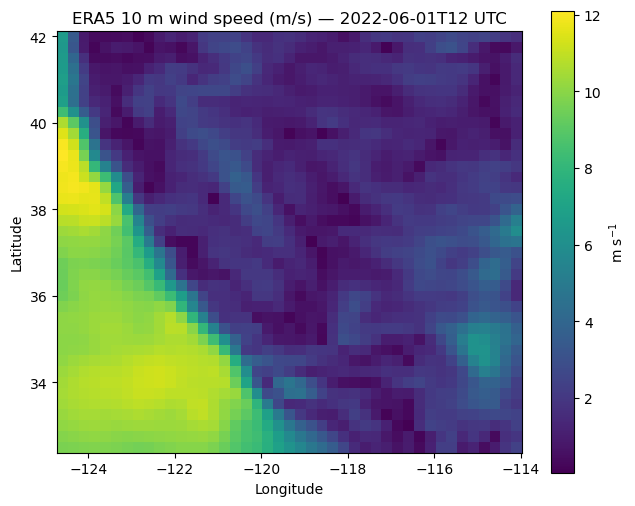

In [8]:
from pathlib import Path
import zipfile
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cdsapi

# --- settings (match your earlier downloads) ---
date_utc = "2022-06-01"
CA_AREA = [42.1, -124.6, 32.5, -114.1]  # [N, W, S, E]
outdir = Path("era5_ca_day")
outdir.mkdir(parents=True, exist_ok=True)

# --- helpers to deal with CDS sometimes returning a ZIP container ---
def extract_zip_netcdfs(path: Path) -> list[Path]:
    with open(path, "rb") as f:
        sig = f.read(4)
    if sig != b"PK\x03\x04":  # not a zip
        return [path]

    out_paths = []
    with zipfile.ZipFile(path, "r") as z:
        nc_members = [m for m in z.namelist() if m.lower().endswith(".nc")]
        if not nc_members:
            raise ValueError(f"{path} is a ZIP but contains no .nc files: {z.namelist()}")
        for m in nc_members:
            z.extract(m, path.parent)
            out_paths.append(path.parent / m)
    return out_paths

def open_cds_netcdf_or_zip(target: Path) -> xr.Dataset:
    nc_paths = extract_zip_netcdfs(target)
    ds = xr.open_mfdataset([str(p) for p in nc_paths], combine="by_coords", engine="netcdf4")
    # normalize time coord name if needed
    if "valid_time" in ds.dims:
        ds = ds.rename({"valid_time": "time"})
    return ds

# --- download 10m wind for the same day/area ---
c = cdsapi.Client()
wind_target = outdir / f"era5_ca_10m_wind_{date_utc.replace('-','')}.nc"

wind_req = {
    "product_type": "reanalysis",
    "variable": [
        "10m_u_component_of_wind",
        "10m_v_component_of_wind",
    ],
    "year": date_utc[0:4],
    "month": date_utc[5:7],
    "day": date_utc[8:10],
    "time": [f"{h:02d}:00" for h in range(24)],
    "area": CA_AREA,
    "data_format": "netcdf",
    "download_format": "unarchived",
}

if not wind_target.exists():
    print("Requesting 10m wind:", wind_target)
    c.retrieve("reanalysis-era5-single-levels", wind_req, str(wind_target))
else:
    print("Wind file exists:", wind_target)

# --- open + compute wind speed ---
ds_wind = open_cds_netcdf_or_zip(wind_target)

# In many CDS NetCDFs, variables come out as short names u10/v10
u = ds_wind["u10"]
v = ds_wind["v10"]
ws = np.sqrt(u**2 + v**2)
ws.name = "wind_speed_10m"
ws.attrs["units"] = "m s-1"
ws.attrs["long_name"] = "10 m wind speed"

# --- choose what to plot ---
# Option A: one hour (e.g., noon UTC)
t_plot = ds_wind["time"].values[12]
ws_plot = ws.sel(time=t_plot)

# Option B: daily mean (uncomment)
# ws_plot = ws.mean("time")

# --- plot (map-like lat/lon plot) ---
fig, ax = plt.subplots(figsize=(7.5, 6))
pcm = ax.pcolormesh(
    ds_wind["longitude"], ds_wind["latitude"], ws_plot,
    shading="auto"
)
ax.set_title(f"ERA5 10 m wind speed (m/s) — {str(t_plot)[:13]} UTC")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
fig.colorbar(pcm, ax=ax, label="m s$^{-1}$")
ax.set_aspect("equal", adjustable="box")
plt.show()


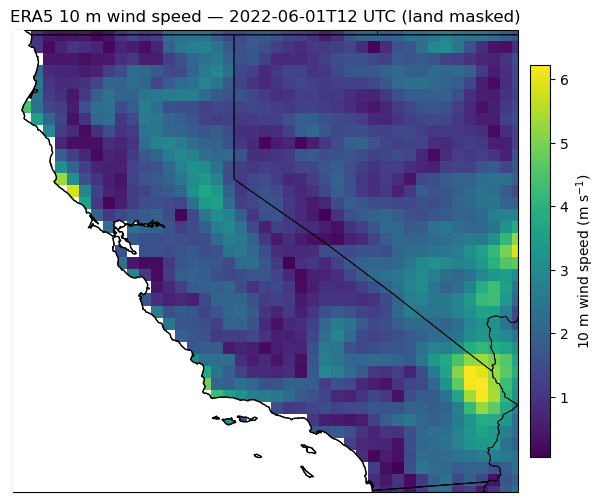

In [9]:
# Add coastlines + mask ocean (land-only) for the ERA5 10 m wind speed map
#
# Conda (if needed):
#   mamba install -c conda-forge -y cartopy shapely

import numpy as np
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader

# --- assume you already have ds_wind open (with dims time/latitude/longitude) ---
# and have computed ws = sqrt(u10^2 + v10^2) as in the previous cell.

# Normalize time coord name if needed
if "valid_time" in ds_wind.dims:
    ds_wind = ds_wind.rename({"valid_time": "time"})

u = ds_wind["u10"]
v = ds_wind["v10"]
ws = np.sqrt(u**2 + v**2)
ws.name = "wind_speed_10m"

# Choose a timestep (e.g., 12:00 UTC)
t_plot = ds_wind["time"].values[12]
ws_plot = ws.sel(time=t_plot)

# -------------------------------------------------------------------
# Build a land mask using Natural Earth land polygons
# -------------------------------------------------------------------
lons = ds_wind["longitude"].values
lats = ds_wind["latitude"].values
lon2d, lat2d = np.meshgrid(lons, lats)

# Natural Earth land shapefile
land_shp = shpreader.natural_earth(resolution="50m", category="physical", name="land")
land_geoms = list(shpreader.Reader(land_shp).geometries())

# Create mask: True where point is on land
land_mask = np.zeros(lon2d.shape, dtype=bool)

# Use shapely if available (fast + robust)
try:
    from shapely.geometry import Point
    from shapely.ops import unary_union
    from shapely.prepared import prep

    land_union = unary_union(land_geoms)
    land_prepped = prep(land_union)

    # Loop is fine here because grid is small (~39x43)
    for i in range(lat2d.shape[0]):
        for j in range(lon2d.shape[1]):
            land_mask[i, j] = land_prepped.contains(Point(float(lon2d[i, j]), float(lat2d[i, j])))

except Exception as e:
    print("Shapely-based land mask failed; falling back to 'paint ocean' overlay.\n", e)
    land_mask = None

# Apply mask (ocean -> NaN)
ws_vals = ws_plot.values
if land_mask is not None:
    ws_vals = np.where(land_mask, ws_vals, np.nan)

# -------------------------------------------------------------------
# Plot with coastlines + land/ocean styling
# -------------------------------------------------------------------
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=proj)

# Set extent to California bbox (or use your CA_AREA)
# CA_AREA is [N, W, S, E]
ax.set_extent([CA_AREA[1], CA_AREA[3], CA_AREA[2], CA_AREA[0]], crs=proj)

# If we couldn't compute a mask, still "mask" visually by drawing ocean on top
# (This hides ocean pixels, but data are still there.)
pcm = ax.pcolormesh(
    lons, lats, ws_vals,
    transform=proj,
    shading="auto",
)

# Add land/ocean + coastlines
ax.add_feature(cfeature.LAND, zorder=2, edgecolor="none", facecolor="none")  # keep transparent
ax.add_feature(cfeature.OCEAN, zorder=3, edgecolor="none", facecolor="white")  # visually mask ocean
ax.coastlines(resolution="10m", linewidth=1.0, zorder=4)

# Optional: add borders / states for context
ax.add_feature(cfeature.BORDERS, linewidth=0.8, zorder=4)
ax.add_feature(cfeature.STATES, linewidth=0.6, zorder=4)

cb = plt.colorbar(pcm, ax=ax, orientation="vertical", shrink=0.85, pad=0.02)
cb.set_label("10 m wind speed (m s$^{-1}$)")

ax.set_title(f"ERA5 10 m wind speed — {str(t_plot)[:13]} UTC (land masked)")
plt.show()


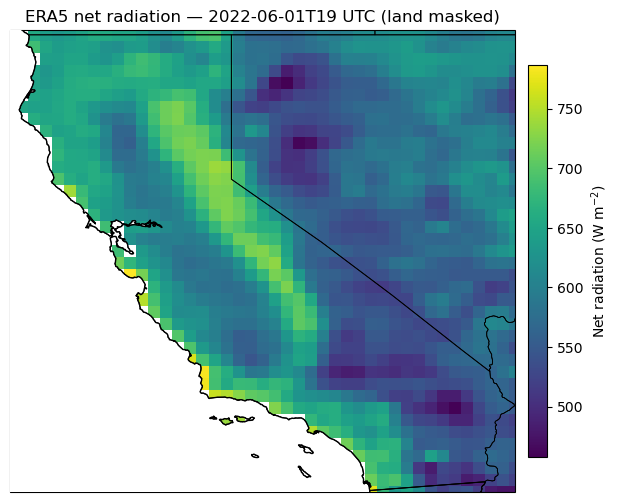

In [10]:
# Map of ERA5 net radiation over CA (land-masked + coastlines), similar to the wind map.
#
# Uses your existing file:
#   era5_ca_day/era5_ca_surface_radiation_YYYYMMDD.nc
#
# Notes:
# - ssr and str are accumulated energy (J m-2 over previous hour).
# - Net radiation flux (W m-2) for a given hour is (ssr + str)/3600.
#
# Conda (if needed):
#   mamba install -c conda-forge -y cartopy shapely

from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader

# -------------------------
# Settings
# -------------------------
date_utc = "2022-06-01"
CA_AREA = [42.1, -124.6, 32.5, -114.1]  # [N, W, S, E]
surface_path = Path(f"era5_ca_day/era5_ca_surface_radiation_{date_utc.replace('-','')}.nc")

# Choose what to plot:
# - a single hour index (0..23), or set hour_idx=None for daily mean
hour_idx = 19  # 12:00 UTC
# hour_idx = None

# -------------------------
# Open + normalize time coordinate
# -------------------------
ds = xr.open_dataset(surface_path, engine="netcdf4")
if "valid_time" in ds.dims:
    ds = ds.rename({"valid_time": "time"})

# Compute net radiation (W m-2)
rn = (ds["ssr"] + ds["str"]) / 3600.0
rn.name = "rn"
rn.attrs["units"] = "W m-2"
rn.attrs["long_name"] = "Surface net radiation (ssr + str) / 3600"

if hour_idx is None:
    rn_plot = rn.mean("time")
    title_time = "daily mean"
else:
    rn_plot = rn.isel(time=hour_idx)
    title_time = str(ds["time"].values[hour_idx])[:13] + " UTC"

lons = ds["longitude"].values
lats = ds["latitude"].values
lon2d, lat2d = np.meshgrid(lons, lats)

# -------------------------
# Land mask (Natural Earth land polygons)
# -------------------------
land_shp = shpreader.natural_earth(resolution="50m", category="physical", name="land")
land_geoms = list(shpreader.Reader(land_shp).geometries())

land_mask = np.zeros(lon2d.shape, dtype=bool)
try:
    from shapely.geometry import Point
    from shapely.ops import unary_union
    from shapely.prepared import prep

    land_union = unary_union(land_geoms)
    land_prepped = prep(land_union)

    # small grid (~39x43) -> loops are fine
    for i in range(lat2d.shape[0]):
        for j in range(lon2d.shape[1]):
            land_mask[i, j] = land_prepped.contains(Point(float(lon2d[i, j]), float(lat2d[i, j])))
except Exception as e:
    print("Shapely land mask failed; will visually mask with OCEAN overlay.\n", e)
    land_mask = None

rn_vals = rn_plot.values
if land_mask is not None:
    rn_vals = np.where(land_mask, rn_vals, np.nan)

# -------------------------
# Plot
# -------------------------
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=proj)

ax.set_extent([CA_AREA[1], CA_AREA[3], CA_AREA[2], CA_AREA[0]], crs=proj)

pcm = ax.pcolormesh(
    lons, lats, rn_vals,
    transform=proj,
    shading="auto"
)

# Coastlines + context
ax.add_feature(cfeature.OCEAN, zorder=3, edgecolor="none", facecolor="white")  # visually hide ocean pixels
ax.coastlines(resolution="10m", linewidth=1.0, zorder=4)
ax.add_feature(cfeature.BORDERS, linewidth=0.8, zorder=4)
ax.add_feature(cfeature.STATES, linewidth=0.6, zorder=4)

cb = plt.colorbar(pcm, ax=ax, orientation="vertical", shrink=0.85, pad=0.02)
cb.set_label("Net radiation (W m$^{-2}$)")

ax.set_title(f"ERA5 net radiation — {title_time} (land masked)")
plt.show()

ds.close()


2026-01-01 09:59:34,920 INFO [2025-12-03T00:00:00Z] To improve our C3S service, we need to hear from you! Please complete this very short [survey](https://confluence.ecmwf.int/x/E7uBEQ/). Thank you.


Requesting model-level T/q (low10): era5_ca_day/era5_ca_ml_tq_low10_20220601_1900.grib


2026-01-01 09:59:35,489 INFO Request ID is 21eee5bc-5133-4ba5-a57f-c8b818d7660b
2026-01-01 09:59:35,694 INFO status has been updated to accepted
2026-01-01 10:00:10,137 INFO status has been updated to successful


2c9f44690ba0b016fce973931e113d87.grib:   0%|          | 0.00/90.9k [00:00<?, ?B/s]

Requesting surface z + lnsp (ML=1): era5_ca_day/era5_ca_ml_zlnsp_20220601_1900.grib


2026-01-01 10:00:13,640 INFO Request ID is 0a21b962-23c1-4476-a69d-bb5868926dea
2026-01-01 10:00:13,841 INFO status has been updated to accepted
2026-01-01 10:00:30,404 INFO status has been updated to running
2026-01-01 10:00:38,208 INFO status has been updated to successful


6700826ce0ac66e1ea5cd2f5da808d06.grib:   0%|          | 0.00/9.09k [00:00<?, ?B/s]

Lon range: -124.60000000000002 -114.10000000000002
T50°C range: 9.207450296663808 34.57847138532668
Land mask True fraction: 0.7262969588550984


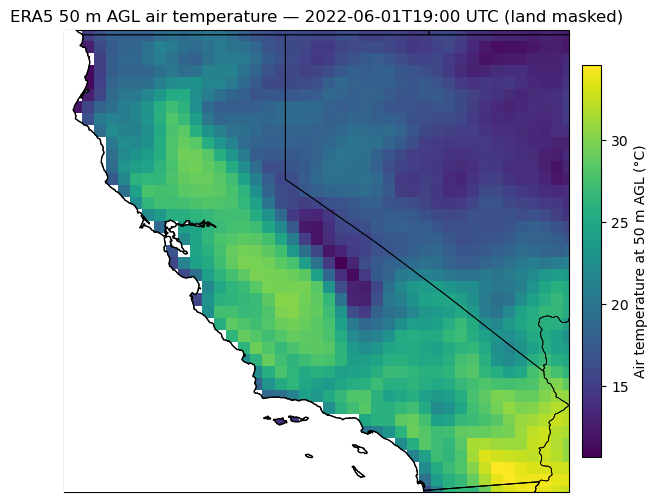

In [11]:
# ERA5 50 m AGL air temperature map over CA (with coastlines + ocean mask)
# - Downloads ERA5-complete GRIB (T,q on lowest 10 model levels + z,lnsp) for ONE hour
# - Computes height AGL from hybrid levels using a/b (pv), lnsp, and surface geopotential
# - Interpolates temperature to 50 m AGL at each grid cell
# - Wraps longitudes to [-180,180] (common cause of "blank map")
# - Masks ocean (land-only) using Natural Earth land polygons (Shapely), with a safe fallback
#
# Conda:
#   mamba install -c conda-forge -y cdsapi xarray cfgrib eccodes netcdf4 cartopy shapely

from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cdsapi

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader

# -------------------------
# Settings
# -------------------------
date_utc = "2022-06-01"
time_utc = "19:00"  # 19 UTC ~ noon CA during PDT
CA_AREA = [42.1, -124.6, 32.5, -114.1]  # [N, W, S, E]
grid = (0.25, 0.25)
target_height_m = 50.0

outdir = Path("era5_ca_day")
outdir.mkdir(parents=True, exist_ok=True)

LOWEST_10_LEVELS = "/".join(str(L) for L in range(128, 138))  # 128..137 inclusive

tag = f"{date_utc.replace('-','')}_{time_utc.replace(':','')}"
tq_grib = outdir / f"era5_ca_ml_tq_low10_{tag}.grib"
zlnsp_grib = outdir / f"era5_ca_ml_zlnsp_{tag}.grib"

# -------------------------
# Download (GRIB) if needed
# -------------------------
c = cdsapi.Client()
hh = time_utc.split(":")[0]

if not tq_grib.exists():
    print("Requesting model-level T/q (low10):", tq_grib)
    c.retrieve(
        "reanalysis-era5-complete",
        {
            "date": date_utc,
            "levtype": "ml",
            "levelist": LOWEST_10_LEVELS,
            "param": "130/133",  # t, q
            "stream": "oper",
            "type": "an",
            "time": hh,
            "area": CA_AREA,
            "grid": [grid[0], grid[1]],
            "format": "grib",
        },
        str(tq_grib),
    )
else:
    print("Exists:", tq_grib)

if not zlnsp_grib.exists():
    print("Requesting surface z + lnsp (ML=1):", zlnsp_grib)
    c.retrieve(
        "reanalysis-era5-complete",
        {
            "date": date_utc,
            "levtype": "ml",
            "levelist": "1",
            "param": "129/152",  # z, lnsp
            "stream": "oper",
            "type": "an",
            "time": hh,
            "area": CA_AREA,
            "grid": [grid[0], grid[1]],
            "format": "grib",
        },
        str(zlnsp_grib),
    )
else:
    print("Exists:", zlnsp_grib)

# -------------------------
# Physics constants
# -------------------------
RD = 287.06
G0 = 9.80665
KAPPA_Q = 0.608  # ~ (Rv/Rd - 1)

# -------------------------
# GRIB helpers (via cfgrib engine)
# -------------------------
def _open_grib(path, short, read_keys=None):
    ds = xr.open_dataset(
        str(path),
        engine="cfgrib",
        backend_kwargs={
            "filter_by_keys": {"shortName": short},
            "read_keys": read_keys or [],
            "indexpath": "",
        },
    )
    if "valid_time" in ds.dims:
        ds = ds.rename({"valid_time": "time"})
    if "step" in ds.dims and ds.dims["step"] == 1:
        ds = ds.isel(step=0, drop=True)
    if "expver" in ds.dims:
        ds = ds.isel(expver=0, drop=True)
    return ds

def _get_ab_from_pv(ds_ml_t, varname="t"):
    pv = None
    containers = [
        getattr(ds_ml_t, "attrs", {}),
        getattr(ds_ml_t[varname], "attrs", {}) if varname in ds_ml_t else {},
        getattr(ds_ml_t[varname], "encoding", {}) if varname in ds_ml_t else {},
        getattr(ds_ml_t, "encoding", {}),
    ]
    for c in containers:
        if c is None:
            continue
        pv = c.get("GRIB_pv")
        if pv is not None:
            break
    if pv is None:
        keys_ds = list(getattr(ds_ml_t, "attrs", {}).keys())
        keys_var = list(getattr(ds_ml_t[varname], "attrs", {}).keys()) if varname in ds_ml_t else []
        raise ValueError(
            "pv (hybrid a/b coefficients) not found.\n"
            f"Dataset attrs keys include: {keys_ds[:25]} ...\n"
            f"{varname} attrs keys include: {keys_var[:25]} ..."
        )
    pv = np.asarray(pv, dtype=np.float64)
    if pv.size % 2 != 0:
        raise ValueError(f"Unexpected pv length: {pv.size}")
    n = pv.size // 2
    return pv[:n], pv[n:]  # a (Pa), b

# -------------------------
# Core computation: T(z=50m AGL)
# -------------------------
def compute_T_at_height(tq_grib: Path, zlnsp_grib: Path, target_height_m: float = 50.0) -> xr.DataArray:
    ds_t    = _open_grib(tq_grib, "t", read_keys=["pv"])
    ds_q    = _open_grib(tq_grib, "q")
    ds_z    = _open_grib(zlnsp_grib, "z")
    ds_lnsp = _open_grib(zlnsp_grib, "lnsp")

    # drop time if present (single hour request)
    for name in ["t", "q", "z", "lnsp"]:
        ds = {"t": ds_t, "q": ds_q, "z": ds_z, "lnsp": ds_lnsp}[name]
        if "time" in ds.dims and ds.dims["time"] == 1:
            ds = ds.isel(time=0, drop=True)
        if name == "t": ds_t = ds
        if name == "q": ds_q = ds
        if name == "z": ds_z = ds
        if name == "lnsp": ds_lnsp = ds

    # vertical dim name
    if "level" in ds_t.dims:
        vdim = "level"
    elif "hybrid" in ds_t.dims:
        vdim = "hybrid"
    else:
        raise ValueError(f"Can't find vertical dim. ds_t.dims={ds_t.dims}")

    levels = ds_t[vdim].values.astype(int)
    nlev = len(levels)

    T = ds_t["t"].values          # (lev, lat, lon)
    q = ds_q["q"].values
    phi_sfc = ds_z["z"].values    # (lat, lon)
    sp = np.exp(ds_lnsp["lnsp"].values)

    if T.ndim != 3:
        raise ValueError(f"Expected T to be 3-D (lev,lat,lon). Got shape={T.shape}")
    if phi_sfc.ndim != 2:
        raise ValueError(f"Expected surface geopotential z to be 2-D. Got shape={phi_sfc.shape}")

    ny, nx = phi_sfc.shape

    a, b = _get_ab_from_pv(ds_t, varname="t")

    min_lv = int(levels.min())
    max_lv = int(levels.max())

    # half-level indices needed: min_lv-1 .. max_lv
    half_idx = np.arange(min_lv - 1, max_lv + 1)
    nh = len(half_idx)

    a_sub = a[half_idx]
    b_sub = b[half_idx]

    # p_half(lat, lon, nh)
    p_half = a_sub[None, None, :] + b_sub[None, None, :] * sp[:, :, None]

    lev_to_i = {int(lv): i for i, lv in enumerate(levels)}

    # p_ml(lev, lat, lon)
    p_ml = np.empty((nlev, ny, nx), dtype=np.float64)
    for lv in levels:
        i = lev_to_i[int(lv)]
        idx_above = (lv - 1) - (min_lv - 1)
        idx_below = (lv) - (min_lv - 1)
        p_ml[i, :, :] = 0.5 * (p_half[:, :, idx_above] + p_half[:, :, idx_below])

    Tv = T * (1.0 + KAPPA_Q * q)

    # integrate geopotential at half-levels from surface
    phi_half = np.full((ny, nx, nh), np.nan, dtype=np.float64)
    phi_half[:, :, -1] = phi_sfc

    for lv in range(max_lv, min_lv - 1, -1):
        if lv not in lev_to_i:
            continue
        i = lev_to_i[lv]
        idx_below = (lv) - (min_lv - 1)
        idx_above = (lv - 1) - (min_lv - 1)
        dphi = RD * Tv[i, :, :] * np.log(p_half[:, :, idx_below] / p_half[:, :, idx_above])
        phi_half[:, :, idx_above] = phi_half[:, :, idx_below] + dphi

    # full-level geopotential -> z_agl(lev,lat,lon)
    z_agl = np.empty((nlev, ny, nx), dtype=np.float64)
    for lv in levels:
        i = lev_to_i[int(lv)]
        idx_below = (lv) - (min_lv - 1)
        phi_full = phi_half[:, :, idx_below] + RD * Tv[i, :, :] * np.log(p_half[:, :, idx_below] / p_ml[i, :, :])
        z_agl[i, :, :] = (phi_full - phi_sfc) / G0

    # interpolate to target height per grid cell
    Tz = np.full((ny, nx), np.nan, dtype=np.float64)

    zcol = z_agl.reshape(nlev, ny * nx)
    tcol = T.reshape(nlev, ny * nx)

    for j in range(ny * nx):
        zj = zcol[:, j]
        tj = tcol[:, j]
        o = np.argsort(zj)
        zj = zj[o]
        tj = tj[o]
        if np.isfinite(zj).all() and (zj.min() <= target_height_m <= zj.max()):
            Tz.flat[j] = np.interp(target_height_m, zj, tj)

    return xr.DataArray(
        Tz,
        coords={"latitude": ds_t["latitude"], "longitude": ds_t["longitude"]},
        dims=("latitude", "longitude"),
        name="t50m",
        attrs={"units": "K", "long_name": f"Air temperature at {target_height_m:.0f} m AGL (derived from ERA5 model levels)"},
    )

# -------------------------
# Compute
# -------------------------
t50 = compute_T_at_height(tq_grib, zlnsp_grib, target_height_m=target_height_m)
t50_c = t50 - 273.15

# Wrap longitudes to [-180, 180] (fixes "blank map" when lon is 0..360)
if float(t50_c.longitude.max()) > 180:
    t50_c = t50_c.assign_coords(
        longitude=((t50_c.longitude + 180) % 360) - 180
    ).sortby("longitude")

print("Lon range:", float(t50_c.longitude.min()), float(t50_c.longitude.max()))
print("T50°C range:", float(np.nanmin(t50_c.values)), float(np.nanmax(t50_c.values)))

# -------------------------
# Land mask (Natural Earth)
# -------------------------
lons = t50_c["longitude"].values
lats = t50_c["latitude"].values
lon2d, lat2d = np.meshgrid(lons, lats)

land_shp = shpreader.natural_earth(resolution="50m", category="physical", name="land")
land_geoms = list(shpreader.Reader(land_shp).geometries())

land_mask = None
try:
    from shapely.geometry import Point
    from shapely.ops import unary_union
    from shapely.prepared import prep

    land_union = unary_union(land_geoms)
    land_prepped = prep(land_union)

    land_mask = np.zeros(lon2d.shape, dtype=bool)
    for i in range(lat2d.shape[0]):
        for j in range(lat2d.shape[1]):
            land_mask[i, j] = land_prepped.contains(Point(float(lon2d[i, j]), float(lat2d[i, j])))
    print("Land mask True fraction:", float(land_mask.mean()))
except Exception as e:
    print("Land mask failed; will visually mask ocean with OCEAN overlay only.\n", e)

vals = t50_c.values
if land_mask is not None:
    vals = np.where(land_mask, vals, np.nan)

# -------------------------
# Plot
# -------------------------
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=proj)
ax.set_extent([CA_AREA[1], CA_AREA[3], CA_AREA[2], CA_AREA[0]], crs=proj)

pcm = ax.pcolormesh(lons, lats, vals, transform=proj, shading="auto")
ax.add_feature(cfeature.OCEAN, zorder=3, edgecolor="none", facecolor="white")  # visual ocean mask
ax.coastlines(resolution="10m", linewidth=1.0, zorder=4)
ax.add_feature(cfeature.BORDERS, linewidth=0.8, zorder=4)
ax.add_feature(cfeature.STATES, linewidth=0.6, zorder=4)

cb = plt.colorbar(pcm, ax=ax, shrink=0.85, pad=0.02)
cb.set_label("Air temperature at 50 m AGL (°C)")
ax.set_title(f"ERA5 50 m AGL air temperature — {date_utc}T{time_utc} UTC (land masked)")
plt.show()


Random point: lat=38.501, lon=-115.179
File exists: era5_profiles/era5_profile_pl_20220601_1200.nc


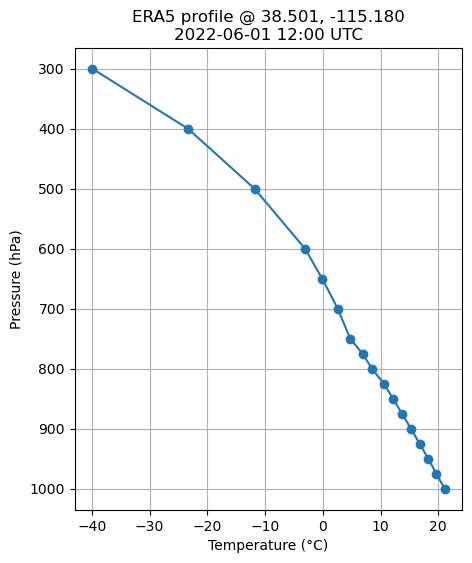

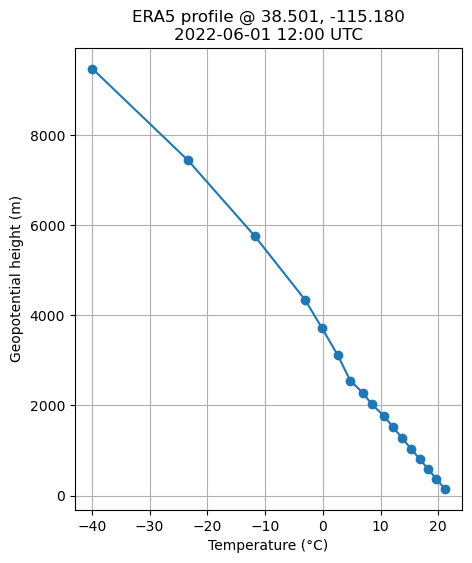

In [15]:
from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cdsapi

# -------------------------
# Settings
# -------------------------
date_utc = "2022-06-01"
time_utc = "12:00"  # pick any hour
CA_AREA = [42.1, -124.6, 32.5, -114.1]  # [N, W, S, E]

# Pick a random point inside CA_AREA
rng = np.random.default_rng(7)
lat0 = rng.uniform(CA_AREA[2], CA_AREA[0])  # S..N
lon0 = rng.uniform(CA_AREA[1], CA_AREA[3])  # W..E
print(f"Random point: lat={lat0:.3f}, lon={lon0:.3f}")

# Small request box around the point (keep tiny)
pad = 0.25
pt_area = [lat0 + pad, lon0 - pad, lat0 - pad, lon0 + pad]  # N,W,S,E

outdir = Path("era5_profiles")
outdir.mkdir(parents=True, exist_ok=True)
out_nc = outdir / f"era5_profile_pl_{date_utc.replace('-','')}_{time_utc.replace(':','')}.nc"

# Pressure levels (hPa) — adjust as you like
plevs = [1000, 975, 950, 925, 900, 875, 850, 825, 800, 775, 750, 700, 650, 600, 500, 400, 300]

# -------------------------
# Download (ERA5 pressure levels)
# -------------------------
c = cdsapi.Client()

req = {
    "product_type": "reanalysis",
    "variable": [
        "temperature",
        "geopotential",  # lets us compute height z = Phi/g
    ],
    "pressure_level": [str(p) for p in plevs],
    "year": date_utc[:4],
    "month": date_utc[5:7],
    "day": date_utc[8:10],
    "time": [time_utc],
    "area": pt_area,
    "data_format": "netcdf",
    "download_format": "unarchived",
}

if not out_nc.exists():
    print("Requesting:", out_nc)
    c.retrieve("reanalysis-era5-pressure-levels", req, str(out_nc))
else:
    print("File exists:", out_nc)

# -------------------------
# Open + extract profile at nearest grid point
# -------------------------
ds = xr.open_dataset(out_nc, engine="netcdf4")

# CDS sometimes uses valid_time
if "valid_time" in ds.dims:
    ds = ds.rename({"valid_time": "time"})

# Identify the pressure dimension name robustly
pdim = "pressure_level" if "pressure_level" in ds.dims else ("level" if "level" in ds.dims else None)
if pdim is None:
    raise ValueError(f"Can't find pressure dimension; dims are: {ds.dims}")

# Select nearest lat/lon
ds_pt = ds.sel(latitude=lat0, longitude=lon0, method="nearest")
T = ds_pt["t"].isel(time=0).values  # K, shape (plev,)
Z = ds_pt["z"].isel(time=0).values  # geopotential (m^2/s^2)
p = ds_pt[pdim].values              # hPa

# Height from geopotential
g0 = 9.80665
z_m = Z / g0

# Sort from high pressure (near surface) to low pressure
order = np.argsort(p)[::-1]
p = p[order]
T = T[order]
z_m = z_m[order]

# -------------------------
# Plot: T vs pressure and T vs height
# -------------------------
fig, ax = plt.subplots(figsize=(5, 6))
ax.plot(T - 273.15, p, marker="o")
ax.invert_yaxis()
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Pressure (hPa)")
ax.set_title(f"ERA5 profile @ {float(ds_pt.latitude):.3f}, {float(ds_pt.longitude):.3f}\n{date_utc} {time_utc} UTC")
ax.grid(True)
plt.show()

fig, ax = plt.subplots(figsize=(5, 6))
ax.plot(T - 273.15, z_m, marker="o")
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Geopotential height (m)")
ax.set_title(f"ERA5 profile @ {float(ds_pt.latitude):.3f}, {float(ds_pt.longitude):.3f}\n{date_utc} {time_utc} UTC")
ax.grid(True)
plt.show()

ds.close()


In [17]:

# https://chatgpt.com/c/6942be28-f8b0-8328-9867-d5919806a9fe